#Loading the Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
base_path = "/content/drive/MyDrive/Movie_Predictor/"

movies = pd.read_csv(base_path + "movies.csv")
ratings = pd.read_csv(base_path + "ratings.csv")
tags = pd.read_csv(base_path + "tags.csv")
links = pd.read_csv(base_path + "links.csv")

print("Loaded successfully.")

Loaded successfully.


In [4]:
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

Movies shape: (87585, 3)
Ratings shape: (32000204, 4)
Tags shape: (2000072, 4)
Links shape: (87585, 3)


In [5]:
display(movies.head())
display(ratings.head())
display(tags.head())
display(links.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [6]:
print("Movies info:")
movies.info()

print("\nRatings info:")
ratings.info()

print("\nTags info:")
tags.info()

print("\nLinks info:")
links.info()

Movies info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB

Ratings info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB

Tags info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000072 entries, 0 to 2000071
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   userId     int64 
 1   movieId    int64 
 2   tag        object
 3   timestamp  int64 
dtypes: int64(3), object(1)
memory usage: 61.0+ MB

Links

In [7]:
print("Missing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in tags:")
print(tags.isnull().sum())

print("\nMissing values in links:")
print(links.isnull().sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in tags:
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64

Missing values in links:
movieId      0
imdbId       0
tmdbId     124
dtype: int64


In [8]:
print("Duplicate rows in movies:", movies.duplicated().sum())
print("Duplicate rows in ratings:", ratings.duplicated().sum())
print("Duplicate rows in tags:", tags.duplicated().sum())
print("Duplicate rows in links:", links.duplicated().sum())

Duplicate rows in movies: 0
Duplicate rows in ratings: 0
Duplicate rows in tags: 0
Duplicate rows in links: 0


In [9]:
print("Unique movies in movies table:", movies["movieId"].nunique())
print("Unique movies in ratings table:", ratings["movieId"].nunique())
print("Unique users in ratings table:", ratings["userId"].nunique())

Unique movies in movies table: 87585
Unique movies in ratings table: 84432
Unique users in ratings table: 200948


In [10]:
df = ratings.merge(movies, on="movieId", how="left")

print("Merged df shape:", df.shape)
display(df.head())

Merged df shape: (32000204, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,17,4.0,944249077,Sense and Sensibility (1995),Drama|Romance
1,1,25,1.0,944250228,Leaving Las Vegas (1995),Drama|Romance
2,1,29,2.0,943230976,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
3,1,30,5.0,944249077,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1,32,5.0,943228858,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller


In [11]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
 4   title      object 
 5   genres     object 
dtypes: float64(1), int64(3), object(2)
memory usage: 1.4+ GB
None
userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


#EDA

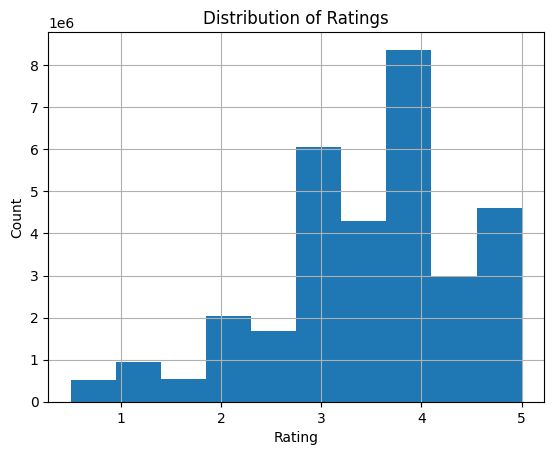

In [12]:
ratings["rating"].hist(bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

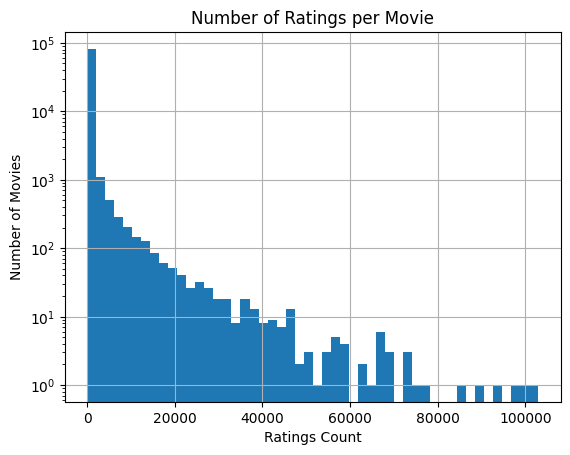

In [13]:

ratings_per_movie = ratings.groupby("movieId")["rating"].count()

ratings_per_movie.hist(bins=50)
plt.title("Number of Ratings per Movie")
plt.xlabel("Ratings Count")
plt.ylabel("Number of Movies")
plt.yscale("log")
plt.show()

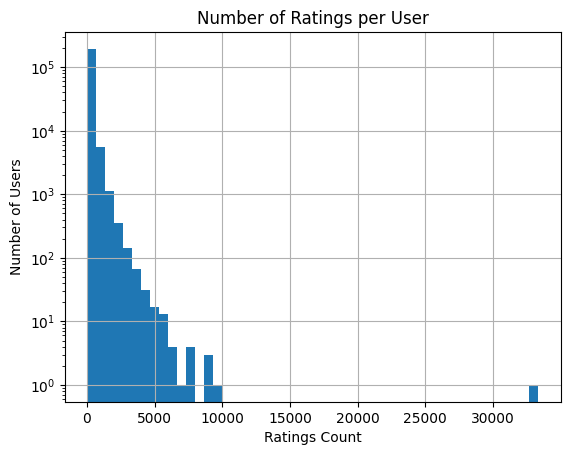

In [14]:
# =========================
# 13. Ratings Per User
# =========================
ratings_per_user = ratings.groupby("userId")["rating"].count()

ratings_per_user.hist(bins=50)
plt.title("Number of Ratings per User")
plt.xlabel("Ratings Count")
plt.ylabel("Number of Users")
plt.yscale("log")
plt.show()

In [15]:
# =========================
# 14. Movie-Level Stats
# =========================
movie_stats = (
    df.groupby(["movieId", "title", "genres"])
    .agg(
        avg_rating=("rating", "mean"),
        num_ratings=("rating", "count")
    )
    .reset_index()
)

display(movie_stats.head(20))
print(movie_stats.describe())

,movieId,title,genres,avg_rating,num_ratings
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.897438,68997
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.275758,28904
2,3,Grumpier Old Men (1995),Comedy|Romance,3.139447,13134
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.845331,2806
4,5,Father of the Bride Part II (1995),Comedy,3.059602,13154
5,6,Heat (1995),Action|Crime|Thriller,3.868277,29490
6,7,Sabrina (1995),Comedy|Romance,3.363968,13585
7,8,Tom and Huck (1995),Adventure|Children,3.115563,1510
8,9,Sudden Death (1995),Action,2.987723,4154
9,10,GoldenEye (1995),Action|Adventure|Thriller,3.427850,32474


             movieId    avg_rating    num_ratings
count   84432.000000  84432.000000   84432.000000
mean   157208.730588      3.005082     379.005638
std     79959.539512      0.801820    2592.439791
min         1.000000      0.500000       1.000000
25%    109373.500000      2.543478       2.000000
50%    166596.000000      3.071429       5.000000
75%    213535.500000      3.500000      25.000000
max    292757.000000      5.000000  102929.000000


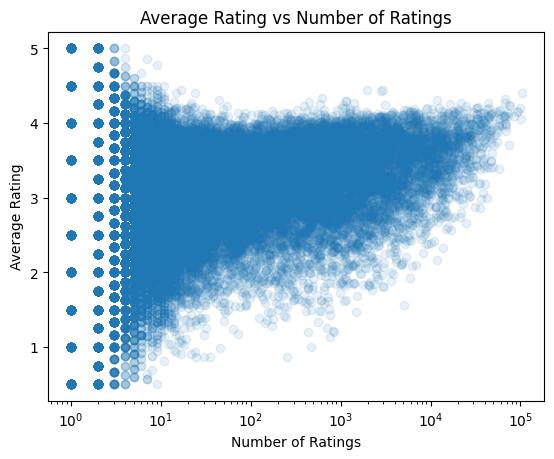

In [16]:
# =========================
# 15. Avg Rating vs Number of Ratings
# =========================
plt.scatter(movie_stats["num_ratings"], movie_stats["avg_rating"], alpha=0.1)
plt.xscale("log")
plt.title("Average Rating vs Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

#User EDA

In [17]:
user_stats = (
    ratings.groupby("userId")
    .agg(
        avg_rating=("rating", "mean"),
        num_ratings=("rating", "count")
    )
    .reset_index()
)

display(user_stats.head())
print(user_stats.describe())

,userId,avg_rating,num_ratings
0,1,3.531915,141
1,2,4.269231,52
2,3,3.588435,147
3,4,2.629630,27
4,5,3.272727,33


              userId     avg_rating    num_ratings
count  200948.000000  200948.000000  200948.000000
mean   100474.500000       3.704368     159.246193
std     58008.835284       0.486573     282.025462
min         1.000000       0.500000      20.000000
25%     50237.750000       3.415385      36.000000
50%    100474.500000       3.725000      73.000000
75%    150711.250000       4.025000     167.000000
max    200948.000000       5.000000   33332.000000


In [18]:
user_stats = (
    ratings.groupby("userId")
    .agg(
        avg_rating=("rating", "mean"),
        num_ratings=("rating", "count"),
        rating_std=("rating", "std")
    )
    .reset_index()
)

display(user_stats.head())
print(user_stats.describe())

,userId,avg_rating,num_ratings,rating_std
0,1,3.531915,141,1.537870
1,2,4.269231,52,1.122242
2,3,3.588435,147,1.014789
3,4,2.629630,27,1.043225
4,5,3.272727,33,0.910794


              userId     avg_rating    num_ratings     rating_std
count  200948.000000  200948.000000  200948.000000  200948.000000
mean   100474.500000       3.704368     159.246193       0.915562
std     58008.835284       0.486573     282.025462       0.269559
min         1.000000       0.500000      20.000000       0.000000
25%     50237.750000       3.415385      36.000000       0.734356
50%    100474.500000       3.725000      73.000000       0.894427
75%    150711.250000       4.025000     167.000000       1.075757
max    200948.000000       5.000000   33332.000000       2.308451


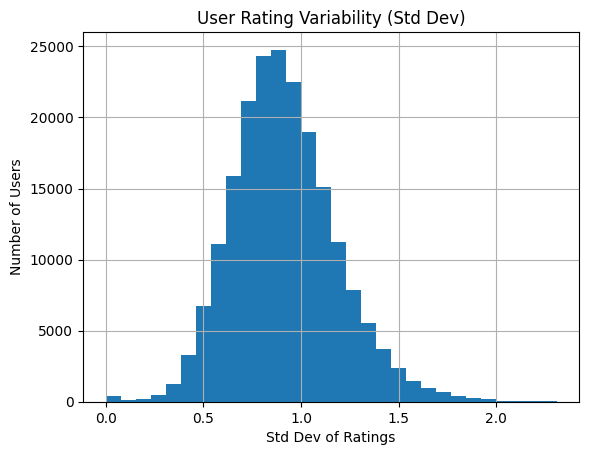

In [19]:
user_stats["rating_std"].hist(bins=30)
plt.title("User Rating Variability (Std Dev)")
plt.xlabel("Std Dev of Ratings")
plt.ylabel("Number of Users")
plt.show()

#Feature Engineering

In [20]:
movie_stats = (
    ratings.groupby("movieId")
    .agg(
        movie_avg_rating=("rating", "mean"),
        movie_num_ratings=("rating", "count")
    )
    .reset_index()
)

display(movie_stats.head())
print(movie_stats.describe())

,movieId,movie_avg_rating,movie_num_ratings
0,1,3.897438,68997
1,2,3.275758,28904
2,3,3.139447,13134
3,4,2.845331,2806
4,5,3.059602,13154


             movieId  movie_avg_rating  movie_num_ratings
count   84432.000000      84432.000000       84432.000000
mean   157208.730588          3.005082         379.005638
std     79959.539512          0.801820        2592.439791
min         1.000000          0.500000           1.000000
25%    109373.500000          2.543478           2.000000
50%    166596.000000          3.071429           5.000000
75%    213535.500000          3.500000          25.000000
max    292757.000000          5.000000      102929.000000


In [21]:
sample_size = 200_000  # safe start

ratings_sample = ratings.sample(n=sample_size, random_state=42).copy()

print(ratings_sample.shape)
display(ratings_sample.head())

(200000, 4)


,userId,movieId,rating,timestamp
10685861,66954,781,5.0,850944577
1552723,9877,574,4.0,945495614
6145184,38348,1088,2.0,999974867
16268584,101952,2706,1.0,1203077565
22418634,140400,275079,3.5,1653782463


In [22]:
# Merge movie info
model_df = ratings_sample.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

# Merge user features
model_df = model_df.merge(user_stats, on="userId", how="left")

# Merge movie features
model_df = model_df.merge(movie_stats, on="movieId", how="left")

print(model_df.shape)
display(model_df.head())

(200000, 11)


,userId,movieId,rating,timestamp,title,genres,avg_rating,num_ratings,rating_std,movie_avg_rating,movie_num_ratings
0,66954,781,5.0,850944577,Stealing Beauty (1996),Drama,3.731183,93,0.724416,3.420905,2143
1,9877,574,4.0,945495614,Spanking the Monkey (1994),Comedy|Drama,3.385042,722,1.259063,3.303319,1416
2,38348,1088,2.0,999974867,Dirty Dancing (1987),Drama|Musical|Romance,3.057906,449,1.056965,3.270196,14112
3,101952,2706,1.0,1203077565,American Pie (1999),Comedy|Romance,3.405914,186,1.324618,3.276009,29519
4,140400,275079,3.5,1653782463,Chip 'n Dale: Rescue Rangers (2022),Adventure|Animation|Children|Comedy|Fantasy|My...,3.468955,1369,0.619452,3.027897,233


In [23]:
model_df["genres"] = model_df["genres"].fillna("(no genres listed)")

genre_dummies = model_df["genres"].str.get_dummies(sep="|")

model_df = pd.concat([model_df, genre_dummies], axis=1)

print("After genre encoding:", model_df.shape)

After genre encoding: (200000, 31)


In [24]:
model_df["rating_std"] = model_df["rating_std"].fillna(0)

In [25]:
feature_cols = [
    "avg_rating",
    "num_ratings",
    "rating_std",
    "movie_avg_rating",
    "movie_num_ratings"
] + list(genre_dummies.columns)

print(feature_cols)

['avg_rating', 'num_ratings', 'rating_std', 'movie_avg_rating', 'movie_num_ratings', '(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [26]:
X = model_df[feature_cols]
y = model_df["rating"]

print(X.shape, y.shape)

(200000, 25) (200000,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 0.8616220872717875


#Recommender

In [42]:
# Clip predictions to valid MovieLens range
preds = np.clip(preds, 0.5, 5.0)

In [43]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("Clipped RMSE:", rmse)

Clipped RMSE: 0.861548905376113


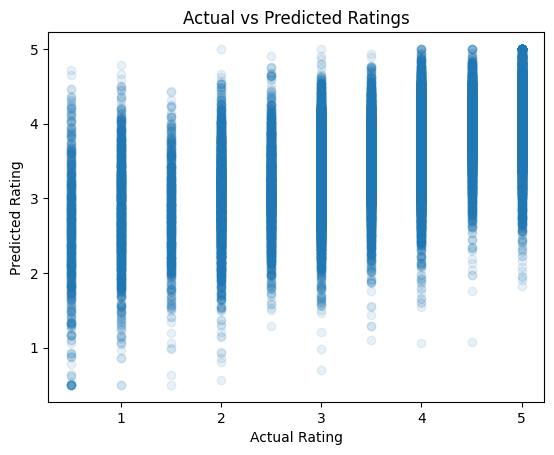

In [44]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds, alpha=0.1)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

In [45]:
feature_cols = X_train.columns.tolist()
print(feature_cols)

['avg_rating', 'num_ratings', 'rating_std', 'movie_avg_rating', 'movie_num_ratings', '(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [46]:
candidate_base = movie_stats.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
).copy()

display(candidate_base.head())

,movieId,movie_avg_rating,movie_num_ratings,title,genres
0,1,3.897438,68997,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.275758,28904,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.139447,13134,Grumpier Old Men (1995),Comedy|Romance
3,4,2.845331,2806,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.059602,13154,Father of the Bride Part II (1995),Comedy


In [47]:
starter_ratings = pd.DataFrame({
    "title": [
        "The Dark Knight (2008)",
        "Inception (2010)",
        "Interstellar (2014)",
        "The Social Network (2010)",
        "Whiplash (2014)"
    ],
    "rating": [5.0, 4.5, 5.0, 4.0, 5.0]
})

In [49]:
starter_profile = starter_ratings.merge(
    candidate_base,
    on="title",
    how="left"
)

display(starter_profile)

,title,rating,movieId,movie_avg_rating,movie_num_ratings,genres
0,The Dark Knight (2008),5.0,NaN,NaN,NaN,NaN
1,Inception (2010),4.5,79132.0,4.157170,57931.0,Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX
2,Interstellar (2014),5.0,109487.0,4.133447,37157.0,Sci-Fi|IMAX
3,The Social Network (2010),4.0,NaN,NaN,NaN,NaN
4,Whiplash (2014),5.0,112552.0,4.154747,19477.0,Drama


In [50]:
user_avg = starter_profile["rating"].mean()
user_count = len(starter_profile)
user_std = starter_profile["rating"].std()

if pd.isna(user_std):
    user_std = 0

print(user_avg, user_count, user_std)

4.7 5 0.4472135954999579


In [51]:
seen_ids = set(starter_profile["movieId"])

rec_df = candidate_base[
    ~candidate_base["movieId"].isin(seen_ids)
].copy()

In [52]:
rec_df["avg_rating"] = user_avg
rec_df["num_ratings"] = user_count
rec_df["rating_std"] = user_std

In [53]:
rec_df["genres"] = rec_df["genres"].fillna("(no genres listed)")

genre_dummies = rec_df["genres"].str.get_dummies(sep="|")

rec_df = pd.concat([rec_df, genre_dummies], axis=1)

In [54]:
for col in feature_cols:
    if col not in rec_df.columns:
        rec_df[col] = 0

X_rec = rec_df[feature_cols]

In [55]:
rec_df["predicted_rating"] = model.predict(X_rec)

# ✅ Fix range (IMPORTANT)
rec_df["predicted_rating"] = np.clip(rec_df["predicted_rating"], 0.5, 5.0)

# Optional: round to half-stars
rec_df["predicted_rating"] = (
    rec_df["predicted_rating"] * 2
).round() / 2

In [56]:
rec_df = rec_df[
    rec_df["movie_num_ratings"] >= 100
].copy()

In [57]:
top_recs = rec_df.sort_values(
    ["predicted_rating", "movie_avg_rating", "movie_num_ratings"],
    ascending=[False, False, False]
)[["title", "predicted_rating", "movie_avg_rating", "movie_num_ratings"]].head(10)

display(top_recs)

,title,predicted_rating,movie_avg_rating,movie_num_ratings
44190,Planet Earth II (2016),5.0,4.446830,1956
39306,Planet Earth (2006),5.0,4.444369,2948
44042,Band of Brothers (2001),5.0,4.426539,2811
314,"Shawshank Redemption, The (1994)",5.0,4.404614,102929
44416,Cosmos,5.0,4.330081,615
840,"Godfather, The (1972)",5.0,4.317030,66440
58698,Parasite (2019),5.0,4.312254,11670
47975,Blue Planet II (2017),5.0,4.300086,1163
56760,Twin Peaks (1989),5.0,4.298684,1140
65936,Twelve Angry Men (1954),5.0,4.286192,449


#Real User Prediction

In [59]:
user_stats.sort_values("num_ratings", ascending=False).head(10)

,userId,avg_rating,num_ratings,rating_std
175324,175325,3.077808,33332,0.742911
17034,17035,2.567819,9577,1.042948
55652,55653,3.280290,9178,0.560175
123464,123465,2.528859,9044,1.267756
171794,171795,3.181954,9016,0.522458
10201,10202,3.411655,7748,0.984570
198514,198515,2.822755,7594,0.930053
49304,49305,3.208868,7488,0.947946
22743,22744,2.640193,7372,1.201871
7857,7858,1.549850,7322,1.241653


In [60]:
test_user_id = 1

In [62]:
user_history = df[df["userId"] == test_user_id].copy()

print(user_history.shape)
display(user_history[["title", "rating", "genres"]].sort_values("rating", ascending=False).head(100))

(141, 6)


,title,rating,genres
4,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),5.0,Mystery|Sci-Fi|Thriller
3,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,5.0,Crime|Drama
11,"Doom Generation, The (1995)",5.0,Comedy|Crime|Drama
9,Taxi Driver (1976),5.0,Crime|Drama|Thriller
7,"White Balloon, The (Badkonake sefid) (1995)",5.0,Children|Drama
...,...,...,...
81,Butch Cassidy and the Sundance Kid (1969),3.0,Action|Western
79,"Room with a View, A (1986)",3.0,Drama|Romance
50,Cinema Paradiso (Nuovo cinema Paradiso) (1989),3.0,Drama
103,Saving Private Ryan (1998),3.0,Action|Drama|War


In [63]:
user_row = user_stats[user_stats["userId"] == test_user_id].iloc[0]

user_avg = user_row["avg_rating"]
user_count = user_row["num_ratings"]
user_std = user_row["rating_std"]

print(user_avg, user_count, user_std)

3.5319148936170213 141.0 1.5378704733185977


In [64]:
candidate_base = movie_stats.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
).copy()

In [70]:
# Remove movies user already saw
seen_ids = set(user_history["movieId"])

rec_df = candidate_base[
    ~candidate_base["movieId"].isin(seen_ids)
].copy()

# Add user features
rec_df["avg_rating"] = user_avg
rec_df["num_ratings"] = user_count
rec_df["rating_std"] = user_std

# Genres
rec_df["genres"] = rec_df["genres"].fillna("(no genres listed)")
genre_dummies = rec_df["genres"].str.get_dummies(sep="|")
rec_df = pd.concat([rec_df, genre_dummies], axis=1)

# Add any missing feature columns
for col in feature_cols:
    if col not in rec_df.columns:
        rec_df[col] = 0

# Filter credible movies first
rec_df = rec_df[rec_df["movie_num_ratings"] >= 100].copy()

# Build model matrix after filtering
X_rec = rec_df[feature_cols].copy()

# Predict
rec_df["predicted_rating"] = model.predict(X_rec)

# Keep predictions in valid range
rec_df["predicted_rating"] = np.clip(rec_df["predicted_rating"], 0.5, 5.0)
rec_df["predicted_rating"] = np.round(rec_df["predicted_rating"] * 2) / 2

# Top recommendations
top_recs = rec_df.sort_values(
    ["predicted_rating", "movie_avg_rating", "movie_num_ratings"],
    ascending=[False, False, False]
)[["title", "predicted_rating", "movie_avg_rating", "movie_num_ratings"]].head(50)

display(top_recs)

,title,predicted_rating,movie_avg_rating,movie_num_ratings
44190,Planet Earth II (2016),4.5,4.446830,1956
39306,Planet Earth (2006),4.5,4.444369,2948
44042,Band of Brothers (2001),4.5,4.426539,2811
47975,Blue Planet II (2017),4.5,4.300086,1163
314,"Shawshank Redemption, The (1994)",4.0,4.404614,102929
44416,Cosmos,4.0,4.330081,615
840,"Godfather, The (1972)",4.0,4.317030,66440
58698,Parasite (2019),4.0,4.312254,11670
56760,Twin Peaks (1989),4.0,4.298684,1140
65936,Twelve Angry Men (1954),4.0,4.286192,449
